# 03 - Visualization Pack (Deliverable C)

**Team Adwa** - Qiyas / IADE Hackathon, Addis Ababa University

Twelve figures, one file each, saved to `figures/` under the exact required names at 150 dpi
(>= 1,200 px wide). One consistent, colorblind-safe style (Okabe-Ito palette) across the pack.
The last cell writes `figures/figure_captions.md`.

fig01-fig09 come from the raw and master tables; fig10-fig12 come from the evaluation artifacts
produced by `src.train.build_artifacts` (same code the modeling notebook uses, so the numbers
always agree).

In [1]:
%matplotlib inline
from pathlib import Path
import os, sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 60)

from src import cleaning as cl
from src import features as ft
from src import train as tr

raw = {k: cl.read_raw(k) for k in ["train", "test", "weather", "prices"]}
master = pd.read_csv("data/processed/master_train.csv")
weather, _ = cl.clean_weather(raw["weather"])
prices, _ = cl.clean_prices(raw["prices"])
captions = {}
print("master:", master.shape)

master: (15090, 25)


In [2]:
# One visual style for the whole pack (colorblind-safe Okabe-Ito palette)
PALETTE = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9",
           "#D55E00", "#F0E442", "#4D4D4D"]
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "-",
    "axes.axisbelow": True, "axes.edgecolor": "#333333",
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 11.5, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "figure.dpi": 110,
    "font.family": "DejaVu Sans", "axes.prop_cycle": plt.cycler(color=PALETTE),
})
Path("figures").mkdir(exist_ok=True)

def save(fig, name):
    """Save with the required file name and clear the canvas."""
    path = Path("figures") / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print("saved", path, f"({(path.stat().st_size // 1024)} KB)")
    return path

## fig01 - Missing / invalid values in every column of the three raw tables

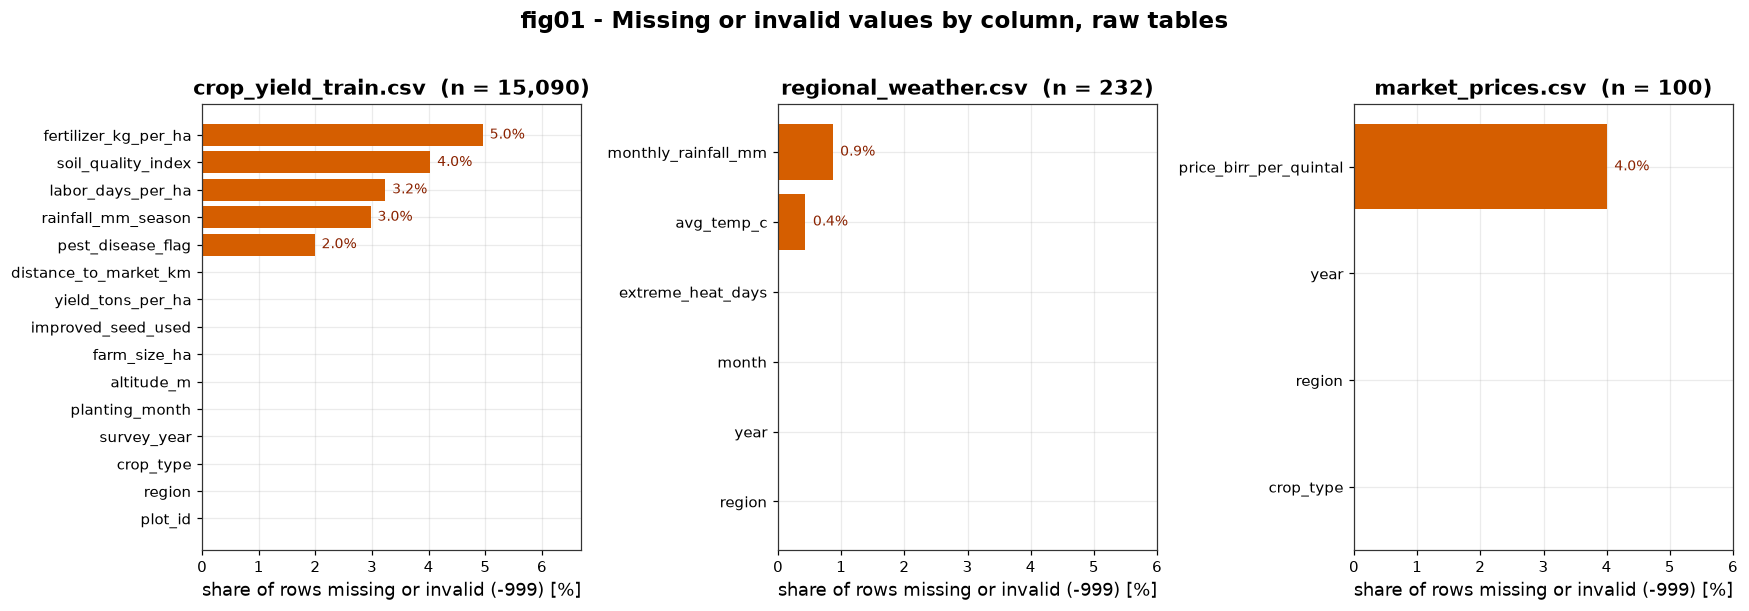

saved figures\fig01_missingness.png (151 KB)
                file                 column      pct
crop_yield_train.csv   fertilizer_kg_per_ha 4.956925
crop_yield_train.csv     soil_quality_index 4.029158
   market_prices.csv price_birr_per_quintal 4.000000
crop_yield_train.csv      labor_days_per_ha 3.233930
crop_yield_train.csv     rainfall_mm_season 2.975480
crop_yield_train.csv      pest_disease_flag 1.988072
regional_weather.csv    monthly_rainfall_mm 0.862069
regional_weather.csv             avg_temp_c 0.431034


In [3]:
def issue_share(df):
    out = {}
    for c in df.columns:
        s = df[c]
        n_missing = int(s.isna().sum())
        n_sentinel = int(((s <= -999) & s.notna()).sum()) if pd.api.types.is_numeric_dtype(s) else 0
        out[c] = 100.0 * (n_missing + n_sentinel) / len(df)
    return pd.Series(out)

tables = {"crop_yield_train.csv": raw["train"],
          "regional_weather.csv": raw["weather"],
          "market_prices.csv": raw["prices"]}
fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
worst = []
for ax, (name, df) in zip(axes, tables.items()):
    rate = issue_share(df).sort_values()
    ax.barh(rate.index, rate.values, color="#D55E00")
    ax.set_title(f"{name}  (n = {len(df):,})")
    ax.set_xlabel("share of rows missing or invalid (-999) [%]")
    ax.set_xlim(0, max(6, rate.max() * 1.35))
    for col, v in rate.items():
        if v > 0:
            ax.text(v + 0.12, col, f"{v:.1f}%", va="center", fontsize=9, color="#8a2200")
    worst += [(name, col, v) for col, v in rate.items() if v > 0]
fig.suptitle("fig01 - Missing or invalid values by column, raw tables",
             fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "fig01_missingness.png")

worst_df = pd.DataFrame(worst, columns=["file", "column", "pct"]).sort_values("pct", ascending=False)
print(worst_df.head(8).to_string(index=False))
captions["fig01_missingness.png"] = (
    f"Share of rows that are blank or carry the -999 sentinel, per column, for the plot, weather "
    f"and price exports. Problems concentrate in the plot table - fertilizer_kg_per_ha is blank in "
    f"{worst_df[worst_df.column == 'fertilizer_kg_per_ha'].pct.max():.1f}% of train rows and "
    f"labor_days_per_ha carries -999 in "
    f"{worst_df[worst_df.column == 'labor_days_per_ha'].pct.max():.1f}% - plus "
    f"{worst_df[worst_df.file == 'market_prices.csv'].shape[0]} affected price columns; "
    f"so every one of those columns needed an explicit fix before modeling.")

## fig02 - Before and after cleaning (variables whose picture visibly changed)

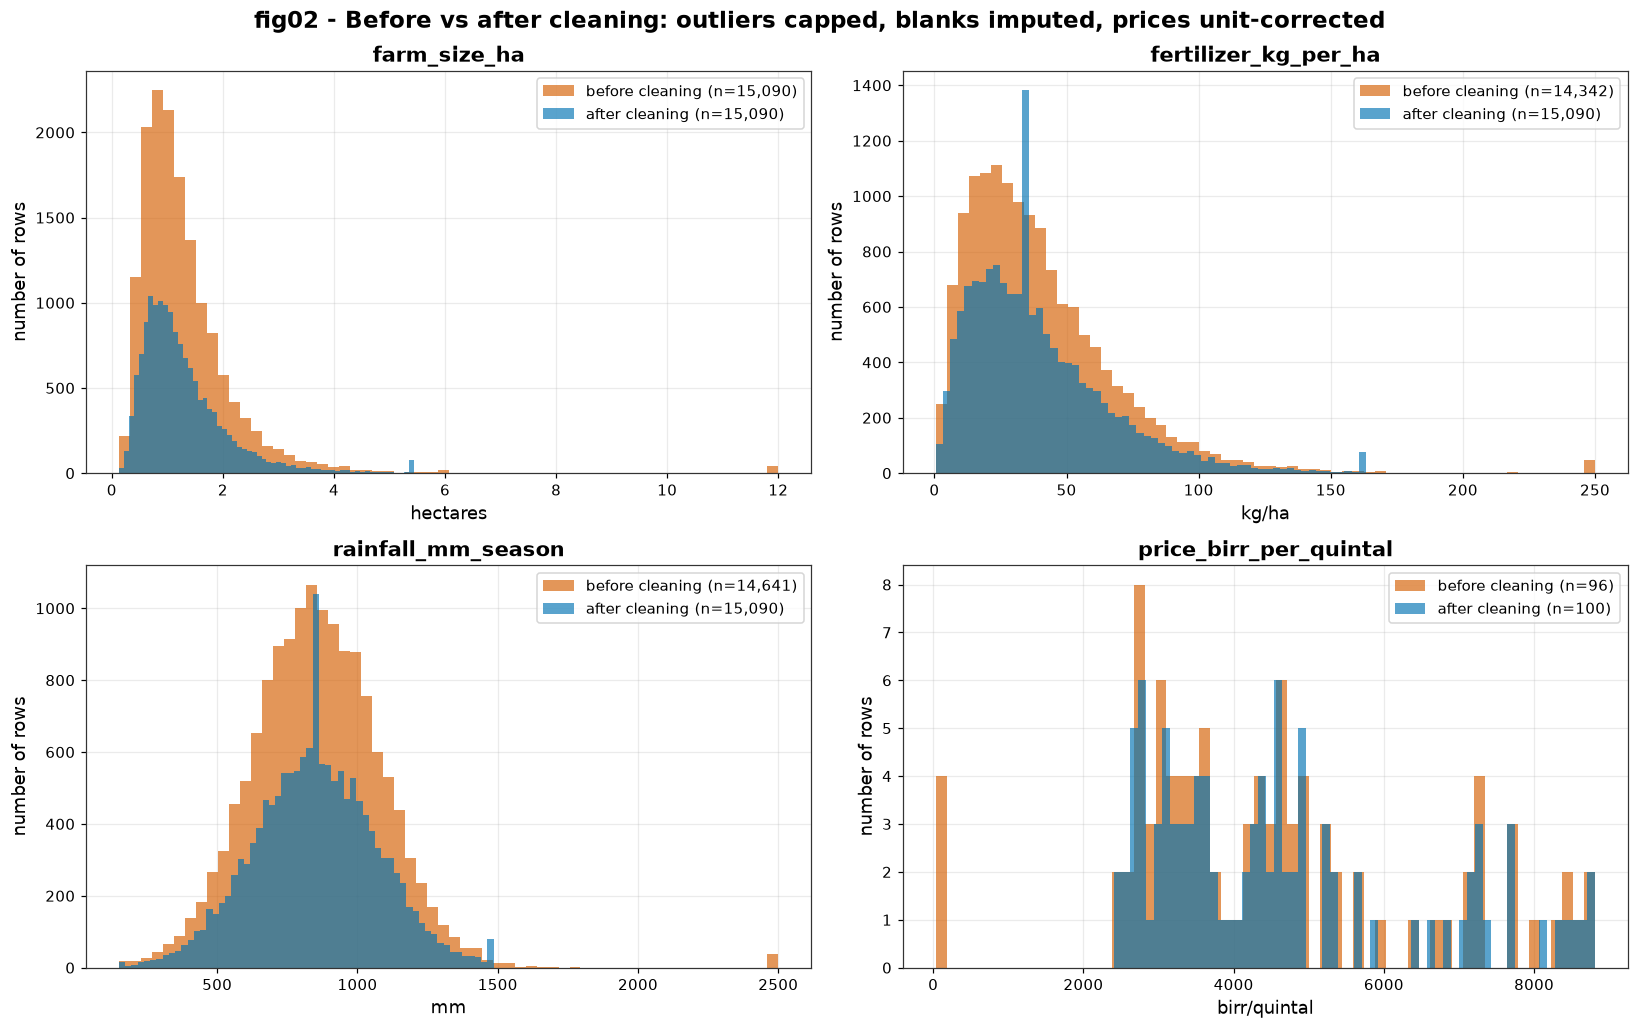

saved figures\fig02_before_after_cleaning.png (149 KB)


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))
panels = [
    (axes[0, 0], raw["train"].farm_size_ha, master.farm_size_ha, "farm_size_ha", "hectares", 0, 12),
    (axes[0, 1], raw["train"].fertilizer_kg_per_ha, master.fertilizer_kg_per_ha,
     "fertilizer_kg_per_ha", "kg/ha", 0, 250),
    (axes[1, 0], raw["train"].rainfall_mm_season, master.rainfall_mm_season,
     "rainfall_mm_season", "mm", 0, 2500),
    (axes[1, 1], raw["prices"].price_birr_per_quintal, prices.price_birr_per_quintal,
     "price_birr_per_quintal", "birr/quintal", 0, 9000),
]
for ax, before, after, col, unit, lo, hi in panels:
    ax.hist(before.dropna().clip(lo, hi), bins=60, alpha=0.65, color="#D55E00",
            label=f"before cleaning (n={before.notna().sum():,})")
    ax.hist(after.dropna().clip(lo, hi), bins=60, alpha=0.65, color="#0072B2",
            label=f"after cleaning (n={after.notna().sum():,})")
    ax.set_title(col)
    ax.set_xlabel(unit)
    ax.set_ylabel("number of rows")
    ax.legend()
fig.suptitle("fig02 - Before vs after cleaning: outliers capped, blanks imputed, prices unit-corrected",
             fontsize=15, fontweight="bold")
fig.tight_layout()
save(fig, "fig02_before_after_cleaning.png")

captions["fig02_before_after_cleaning.png"] = (
    f"Raw versus cleaned distributions. Capping at the train 99.5% percentile trims "
    f"{int((raw['train'].farm_size_ha > 5.44).sum())} farm-size and "
    f"{int((raw['train'].fertilizer_kg_per_ha > 163.28).sum())} fertilizer outliers, "
    f"{int(raw['train'].rainfall_mm_season.isna().sum())} blank rainfall values are filled, and "
    f"4 prices recorded in birr per kg are multiplied by 100, so the price histogram no longer "
    f"shows a spike near zero - without that fix revenue would have been understated 100-fold.")

## fig03 - Yield distribution, overall and by crop type

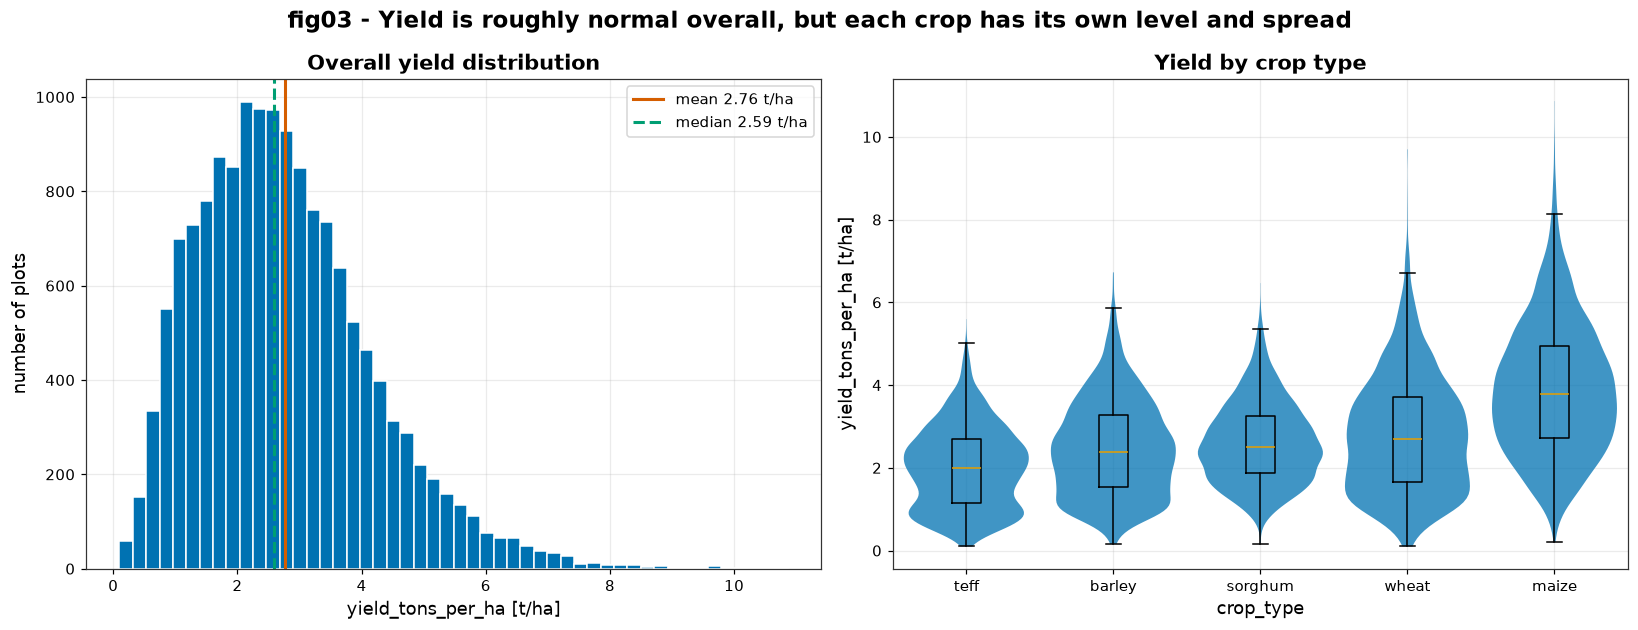

saved figures\fig03_yield_distribution.png (116 KB)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
y = master.yield_tons_per_ha
axes[0].hist(y, bins=50, color="#0072B2", edgecolor="white")
axes[0].axvline(y.mean(), color="#D55E00", lw=2,
                label=f"mean {y.mean():.2f} t/ha")
axes[0].axvline(y.median(), color="#009E73", lw=2, ls="--",
                label=f"median {y.median():.2f} t/ha")
axes[0].set_title("Overall yield distribution")
axes[0].set_xlabel("yield_tons_per_ha [t/ha]")
axes[0].set_ylabel("number of plots")
axes[0].legend()

order = master.groupby("crop_type").yield_tons_per_ha.median().sort_values().index.tolist()
parts = axes[1].violinplot([master.loc[master.crop_type == c, "yield_tons_per_ha"] for c in order],
                       positions=range(len(order)), showextrema=False, widths=0.85)
for pc in parts["bodies"]:
    pc.set_alpha(0.75)
axes[1].boxplot([master.loc[master.crop_type == c, "yield_tons_per_ha"] for c in order],
                positions=range(len(order)), widths=0.2, showfliers=False)
axes[1].set_xticks(range(len(order)), order)
axes[1].set_title("Yield by crop type")
axes[1].set_xlabel("crop_type")
axes[1].set_ylabel("yield_tons_per_ha [t/ha]")
fig.suptitle("fig03 - Yield is roughly normal overall, but each crop has its own level and spread",
             fontsize=15, fontweight="bold")
fig.tight_layout()
save(fig, "fig03_yield_distribution.png")

captions["fig03_yield_distribution.png"] = (
    f"Yield distribution overall (left, mean {y.mean():.2f}, median {y.median():.2f} t/ha) and by "
    f"crop (right). The pooled distribution hides a clear crop ranking: the highest-yielding crop "
    f"centers near {master.groupby('crop_type').yield_tons_per_ha.mean().max():.2f} t/ha against "
    f"{master.groupby('crop_type').yield_tons_per_ha.mean().min():.2f} t/ha for the lowest, so "
    f"crop_type must be in any sensible model.")

## fig04 - Mean yield by region x crop (annotated heatmap with plot counts)

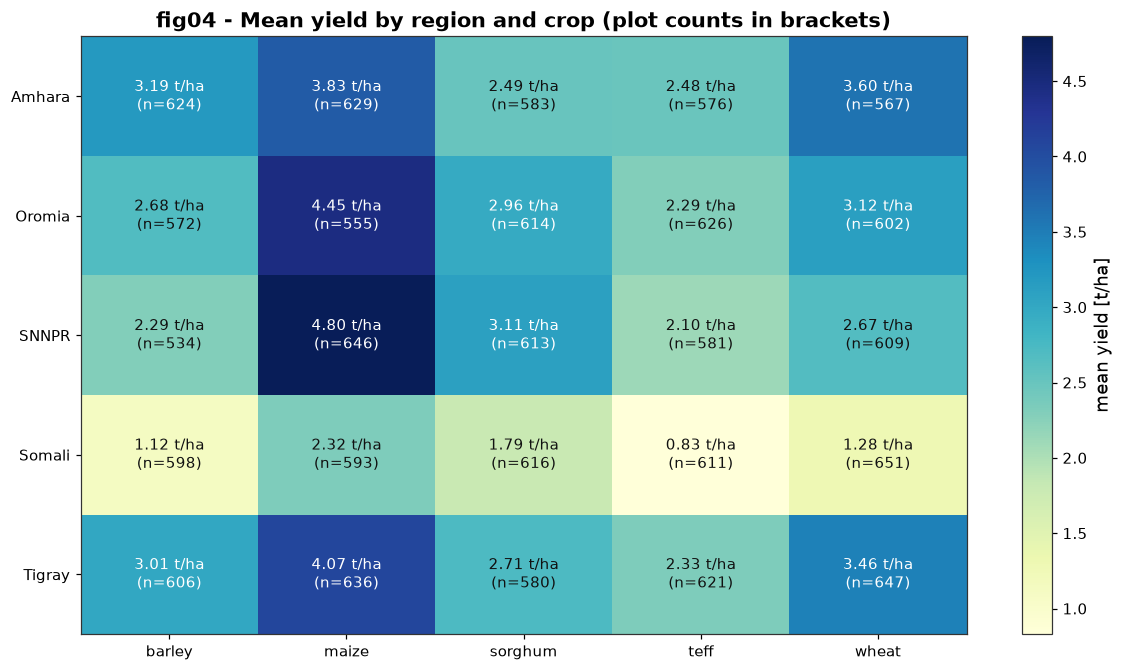

saved figures\fig04_region_crop_heatmap.png (143 KB)


In [6]:
NL = chr(10)
pivot = master.pivot_table(index="region", columns="crop_type",
                            values="yield_tons_per_ha", aggfunc="mean")
counts = master.pivot_table(index="region", columns="crop_type",
                            values="yield_tons_per_ha", aggfunc="size")
fig, ax = plt.subplots(figsize=(11, 6.2))
im = ax.imshow(pivot.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(pivot.shape[1]), pivot.columns)
ax.set_yticks(range(pivot.shape[0]), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f} t/ha" + NL + f"(n={int(counts.values[i, j])})",
                ha="center", va="center", fontsize=10,
                color="white" if pivot.values[i, j] > pivot.values.mean() else "#111111")
cb = fig.colorbar(im, ax=ax)
cb.set_label("mean yield [t/ha]")
ax.set_title("fig04 - Mean yield by region and crop (plot counts in brackets)")
ax.grid(False)
fig.tight_layout()
save(fig, "fig04_region_crop_heatmap.png")

stacked = pivot.stack()
captions["fig04_region_crop_heatmap.png"] = (
    f"Annotated heatmap of mean yield for every region x crop cell with the number of plots. "
    f"Cells run from {stacked.min():.2f} t/ha ({stacked.idxmin()[0]}/{stacked.idxmin()[1]}) to "
    f"{stacked.max():.2f} t/ha ({stacked.idxmax()[0]}/{stacked.idxmax()[1]}) - a "
    f"{stacked.max() - stacked.min():.2f} t/ha spread - and every cell has at least "
    f"{int(counts.values.min())} plots, so the pattern is not small-sample noise.")

## fig05 - Correlation heatmap: yield, numeric plot features and weather-derived features

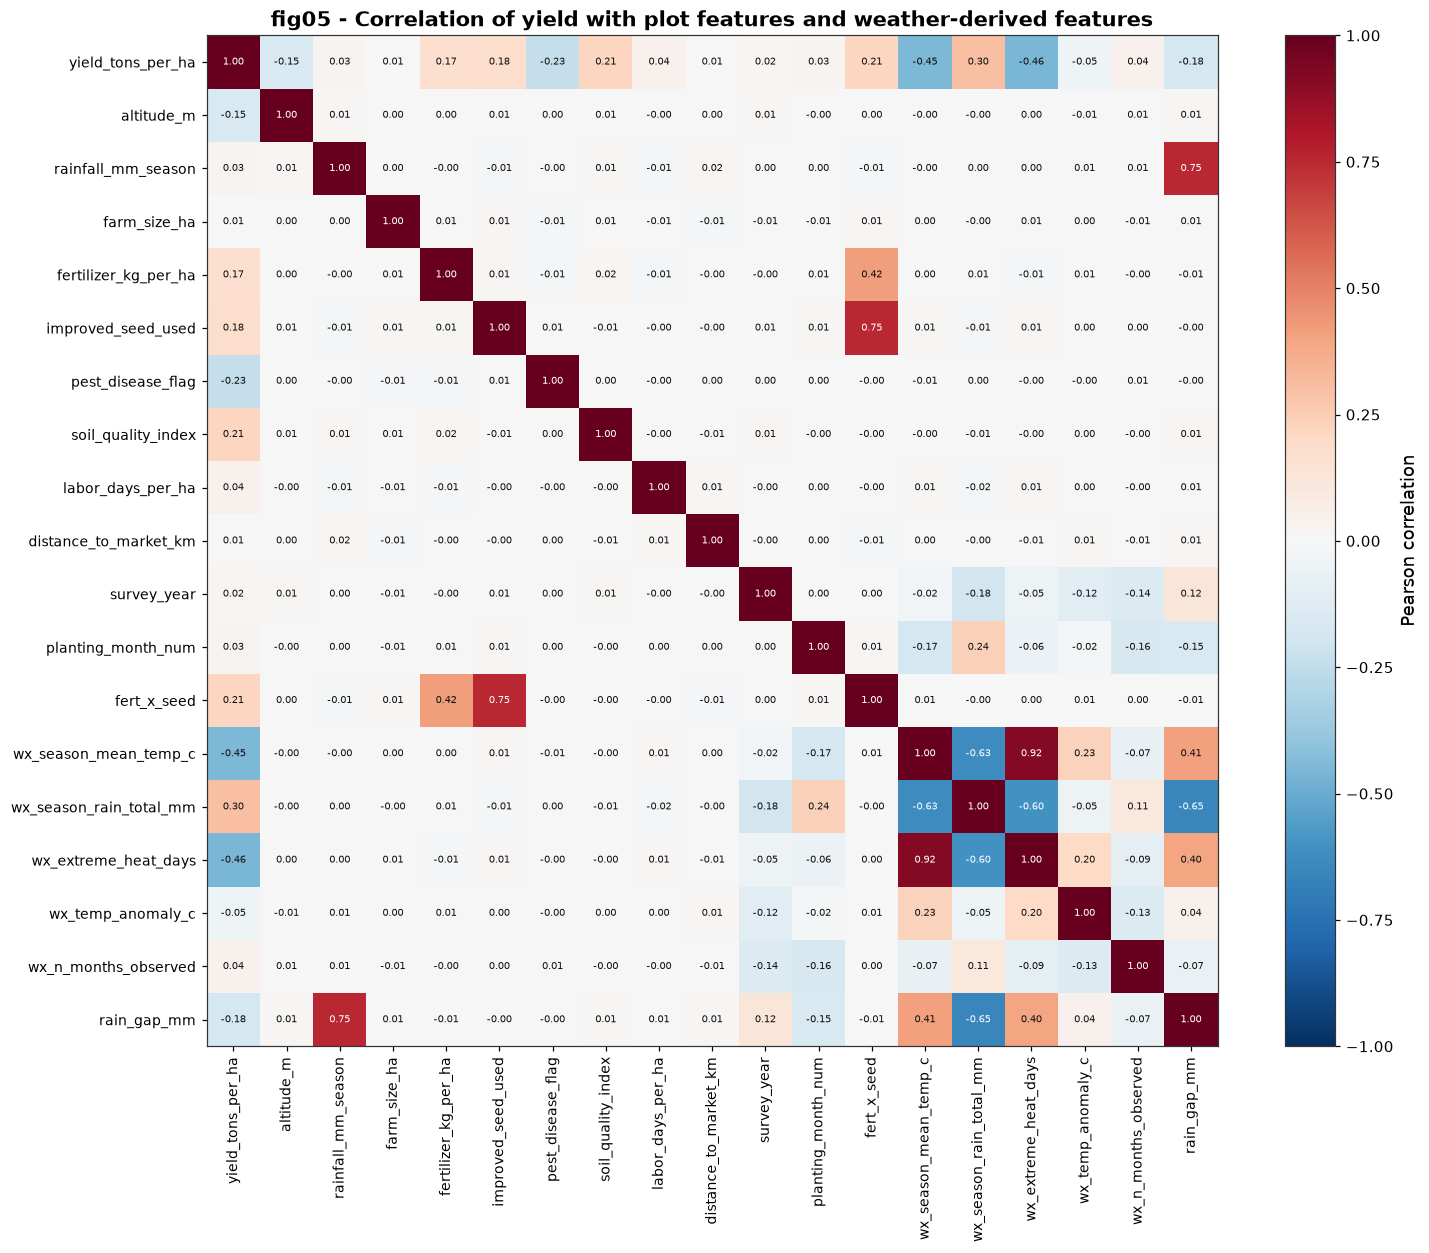

saved figures\fig05_correlation_heatmap.png (324 KB)


In [7]:
corr_cols = ["yield_tons_per_ha", "altitude_m", "rainfall_mm_season", "farm_size_ha",
             "fertilizer_kg_per_ha", "improved_seed_used", "pest_disease_flag",
             "soil_quality_index", "labor_days_per_ha", "distance_to_market_km",
             "survey_year", "planting_month_num", "fert_x_seed",
             "wx_season_mean_temp_c", "wx_season_rain_total_mm", "wx_extreme_heat_days",
             "wx_temp_anomaly_c", "wx_n_months_observed", "rain_gap_mm"]
corr = master[corr_cols].corr()
fig, ax = plt.subplots(figsize=(14, 11.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=90, fontsize=9)
ax.set_yticks(range(len(corr_cols)), corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6.4,
                color="white" if abs(corr.values[i, j]) > 0.6 else "#111111")
cb = fig.colorbar(im, ax=ax, fraction=0.046)
cb.set_label("Pearson correlation")
ax.set_title("fig05 - Correlation of yield with plot features and weather-derived features")
ax.grid(False)
fig.tight_layout()
save(fig, "fig05_correlation_heatmap.png")

y_corr = corr["yield_tons_per_ha"].drop("yield_tons_per_ha").sort_values(key=abs, ascending=False)
wx_corr = [c for c in y_corr.index if c.startswith("wx_") or c == "rain_gap_mm"]
captions["fig05_correlation_heatmap.png"] = (
    f"Correlation matrix of yield with all numeric plot features and every weather-derived feature. "
    f"Yield correlates most with {y_corr.index[0]} ({y_corr.iloc[0]:+.2f}) and "
    f"{y_corr.index[1]} ({y_corr.iloc[1]:+.2f}); among the joined weather features, "
    f"{max(wx_corr, key=lambda c: abs(y_corr[c]))} is the strongest at "
    f"{y_corr[max(wx_corr, key=lambda c: abs(y_corr[c]))]:+.2f}, and the weather columns are "
    f"mostly uncorrelated with the plot rainfall column - they carry different information.")

## fig06 - Monthly climate by region, with a growing-season window shaded

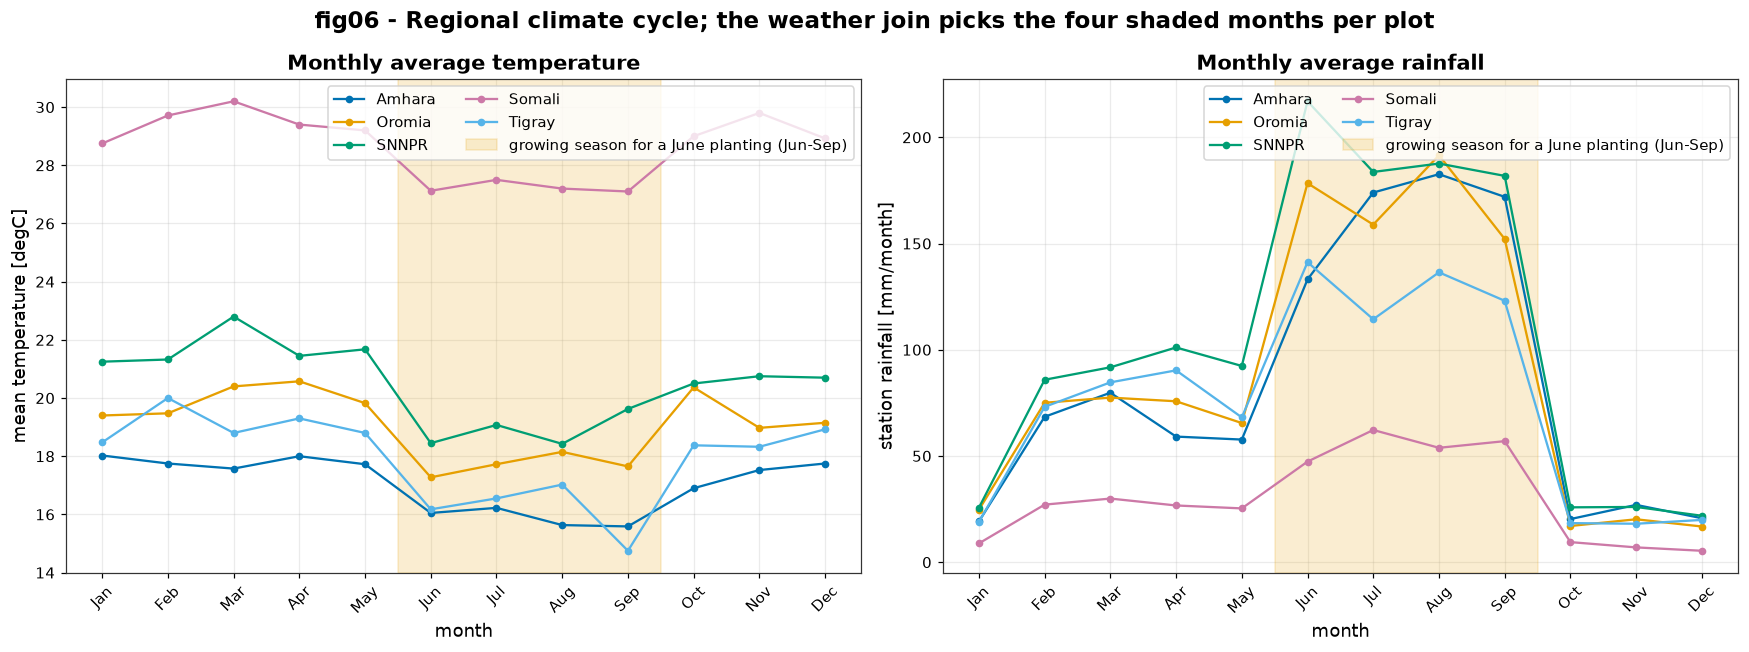

saved figures\fig06_climate_by_region.png (278 KB)


In [8]:
MONTHS = cl.MONTHS
w = weather.copy()
w["month"] = pd.Categorical(w.month, categories=MONTHS, ordered=True)
temp_m = w.pivot_table(index="month", columns="region", values="avg_temp_c", aggfunc="mean")
rain_m = w.pivot_table(index="month", columns="region",
                       values="monthly_rainfall_mm", aggfunc="mean")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, frame, ylabel, title in [
        (axes[0], temp_m, "mean temperature [degC]", "Monthly average temperature"),
        (axes[1], rain_m, "station rainfall [mm/month]", "Monthly average rainfall")]:
    for region in frame.columns:
        ax.plot(frame.index.astype(str), frame[region], marker="o", ms=4, label=region)
    ax.axvspan(4.5, 8.5, color="#E69F00", alpha=0.18,
               label="growing season for a June planting (Jun-Sep)")
    ax.set_title(title)
    ax.set_xlabel("month")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(ncol=2, loc="upper right")
fig.suptitle("fig06 - Regional climate cycle; the weather join picks the four shaded months per plot",
             fontsize=15, fontweight="bold")
fig.tight_layout()
save(fig, "fig06_climate_by_region.png")

hottest = temp_m.mean(axis=1).idxmax()
wettest = rain_m.mean(axis=1).idxmax()
captions["fig06_climate_by_region.png"] = (
    f"Monthly mean temperature and rainfall per region, with the June-planting growing season "
    f"(Jun-Sep) shaded. The regions separate clearly - {temp_m.max().idxmax()} is hottest at "
    f"{temp_m.max().max():.1f} degC in {temp_m.max().idxmax()} and the wettest month overall is "
    f"{wettest} at {rain_m.max().max():.0f} mm - which is why season weather is joined per plot "
    f"window instead of using one annual number.")

## fig07 - Yield against growing-season mean temperature, one panel per crop

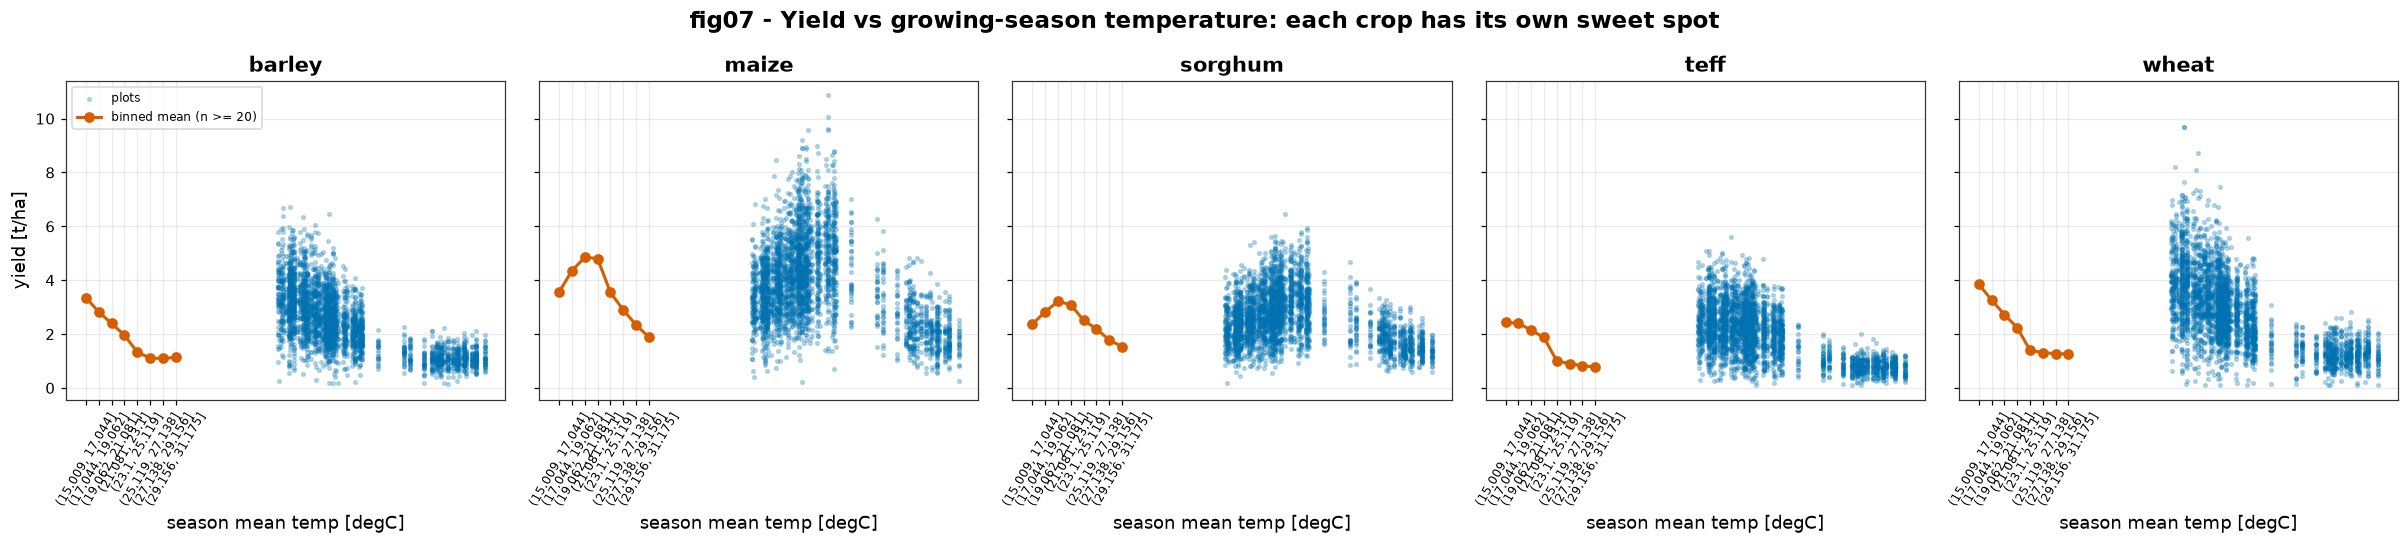

saved figures\fig07_yield_vs_season_temp.png (498 KB)


,crop,sweet_spot_temp_c,peak_mean_yield
0,barley,16.0,3.4
1,maize,20.1,4.9
2,sorghum,20.1,3.2
3,teff,16.0,2.4
4,wheat,16.0,3.9


In [9]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
temp_bins = pd.cut(master.wx_season_mean_temp_c, bins=8)
summary_t = []
for ax, crop in zip(axes, sorted(master.crop_type.unique())):
    sub = master[master.crop_type == crop]
    ax.scatter(sub.wx_season_mean_temp_c, sub.yield_tons_per_ha, s=6, alpha=0.25,
               color="#0072B2", label="plots")
    binned = sub.groupby(pd.cut(sub.wx_season_mean_temp_c, bins=8),
                         observed=True)["yield_tons_per_ha"].agg(["mean", "size"])
    keep = binned[binned["size"] >= 20]
    ax.plot(keep.index.astype(str), keep["mean"], color="#D55E00", marker="o", ms=6, lw=2,
            label="binned mean (n >= 20)")
    if len(keep):
        best_band = keep["mean"].idxmax()
        summary_t.append((crop, float(best_band.mid), keep["mean"].max()))
    ax.set_title(crop)
    ax.set_xlabel("season mean temp [degC]")
    ax.tick_params(axis="x", rotation=60, labelsize=8)
axes[0].set_ylabel("yield [t/ha]")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("fig07 - Yield vs growing-season temperature: each crop has its own sweet spot",
             fontsize=15, fontweight="bold")
fig.tight_layout()
save(fig, "fig07_yield_vs_season_temp.png")

sweet = pd.DataFrame(summary_t, columns=["crop", "sweet_spot_temp_c", "peak_mean_yield"])
display(sweet.round(1))
captions["fig07_yield_vs_season_temp.png"] = (
    f"Yield against the joined growing-season mean temperature, one panel per crop, with binned "
    f"means (bins holding at least 20 plots). Each crop peaks in a different band - sweet spots run "
    f"from {sweet.sweet_spot_temp_c.min():.1f} degC ({sweet.loc[sweet.sweet_spot_temp_c.idxmin(), 'crop']}) "
    f"to {sweet.sweet_spot_temp_c.max():.1f} degC ({sweet.loc[sweet.sweet_spot_temp_c.idxmax(), 'crop']}) - "
    f"so temperature is informative only interacted with crop_type, exactly what a tree model "
    f"learns natively.")

## fig08 - Price per quintal by year and crop (unit-corrected)

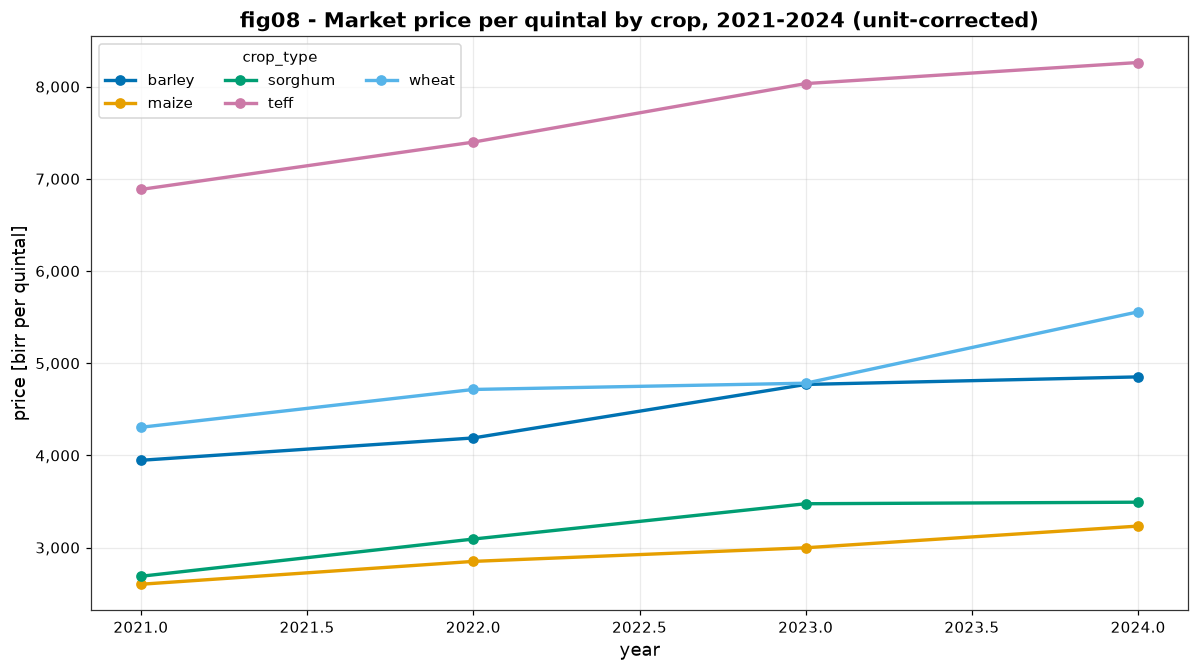

saved figures\fig08_price_trends.png (86 KB)


year,2021,2022,2023,2024
crop_type,,,,
barley,3947.0,4189.0,4770.0,4852.0
maize,2602.0,2850.0,2998.0,3233.0
sorghum,2689.0,3093.0,3476.0,3492.0
teff,6885.0,7398.0,8033.0,8262.0
wheat,4305.0,4715.0,4783.0,5557.0


In [10]:
price_line = prices.groupby(["crop_type", "year"])["price_birr_per_quintal"].mean().unstack("year")
fig, ax = plt.subplots(figsize=(11, 6.2))
for crop in price_line.index:
    ax.plot(price_line.columns, price_line.loc[crop], marker="o", lw=2.2, label=crop)
ax.set_title("fig08 - Market price per quintal by crop, 2021-2024 (unit-corrected)")
ax.set_xlabel("year")
ax.set_ylabel("price [birr per quintal]")
ax.legend(title="crop_type", ncol=3)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:,.0f}")
fig.tight_layout()
save(fig, "fig08_price_trends.png")

display(price_line.round(0))
growth = 100 * (price_line[2024] - price_line[2021]) / price_line[2021]
captions["fig08_price_trends.png"] = (
    f"Average price per quintal by crop and year after the unit fix (four rows recorded in birr per "
    f"kg were multiplied by 100). All five crops rise over the period, fastest is "
    f"{growth.idxmax()} at +{growth.max():.1f}% and slowest {growth.idxmin()} at +{growth.min():.1f}%, "
    f"with teff remaining the most expensive crop at "
    f"{price_line.loc['teff', 2024]:,.0f} birr/quintal - the level that drives the B1.1 revenue "
    f"ranking.")

## fig09 - Revenue per hectare by crop and region

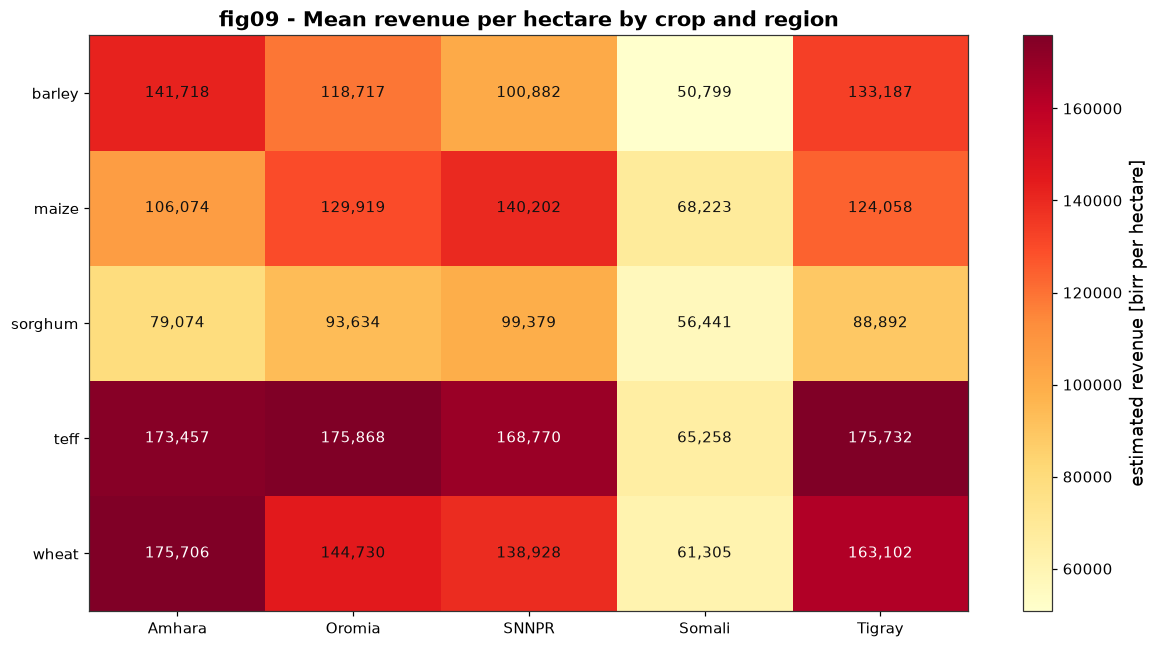

saved figures\fig09_revenue_by_crop_region.png (92 KB)


In [11]:
rev_df = master.copy()
rev_df["revenue_birr_per_ha"] = ft.revenue_per_ha(rev_df.yield_tons_per_ha,
                                                 rev_df.price_birr_per_quintal)
rev = rev_df.pivot_table(index="crop_type", columns="region",
                         values="revenue_birr_per_ha", aggfunc="mean")
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(rev.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(rev.shape[1]), rev.columns)
ax.set_yticks(range(rev.shape[0]), rev.index)
for i in range(rev.shape[0]):
    for j in range(rev.shape[1]):
        ax.text(j, i, f"{rev.values[i, j]:,.0f}", ha="center", va="center", fontsize=10,
                color="white" if rev.values[i, j] > rev.values.mean() * 1.25 else "#111111")
cb = fig.colorbar(im, ax=ax)
cb.set_label("estimated revenue [birr per hectare]")
ax.set_title("fig09 - Mean revenue per hectare by crop and region")
ax.grid(False)
fig.tight_layout()
save(fig, "fig09_revenue_by_crop_region.png")

captions["fig09_revenue_by_crop_region.png"] = (
    f"Revenue per hectare (yield x 10 quintals x price) by crop and region. The best cell is "
    f"{rev.stack().idxmax()[0]}/{rev.stack().idxmax()[1]} at {rev.stack().max():,.0f} birr/ha and the "
    f"worst {rev.stack().idxmin()[0]}/{rev.stack().idxmin()[1]} at {rev.stack().min():,.0f} birr/ha, a "
    f"{rev.stack().max() / rev.stack().min():.1f}x difference - crop choice moves revenue far more "
    f"than region does, which is why the demo reports revenue next to yield.")

## fig10 - Model comparison: validation RMSE for every model tried

                dummy_mean  rmse=1.4131  mae=1.1042  r2=-0.0001  (0.0s)
                     ridge  rmse=0.8814  mae=0.6606  r2=0.6108  (0.0s)


             random_forest  rmse=0.5322  mae=0.3906  r2=0.8581  (1.7s)


    hist_gradient_boosting  rmse=0.4833  mae=0.3519  r2=0.8830  (1.5s)


            mlp_neural_net  rmse=0.4831  mae=0.3537  r2=0.8831  (3.4s)


  cv   hist_gradient_boosting  0.4842 +/- 0.0136


  cv            random_forest  0.5288 +/- 0.0085


  cv           mlp_neural_net  0.4811 +/- 0.0047
  final model family: mlp_neural_net | runner-up: hist_gradient_boosting


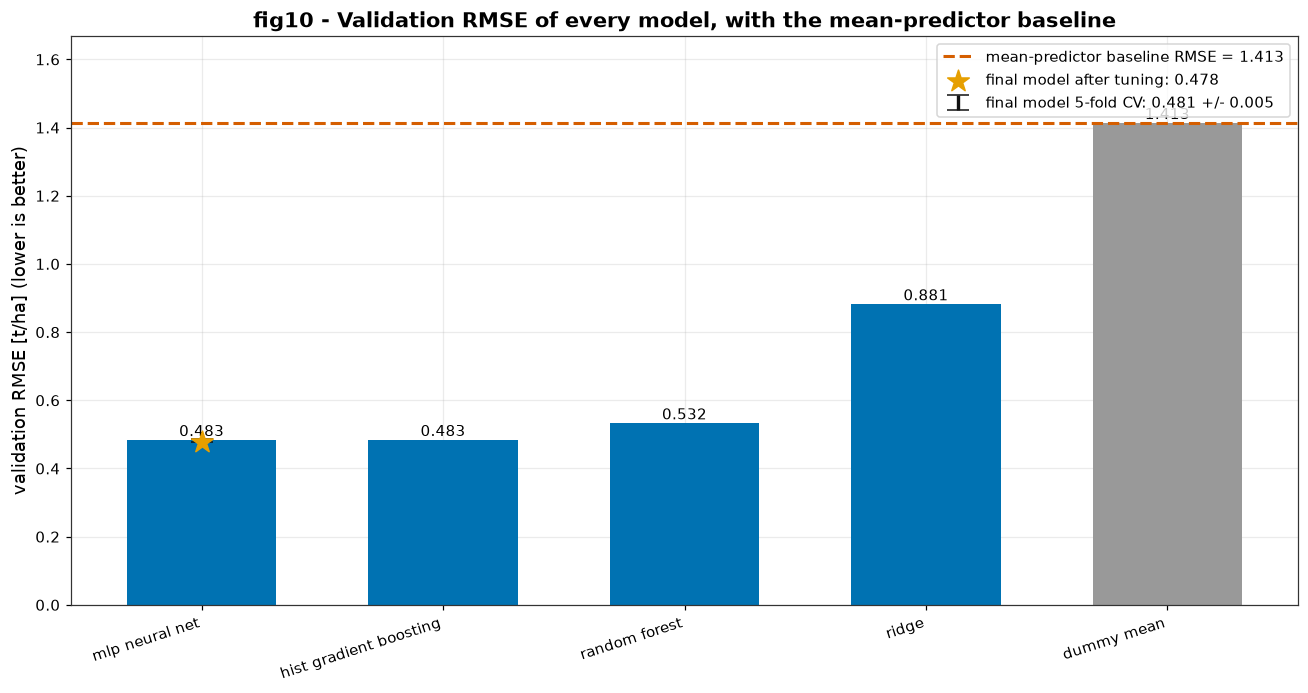

saved figures\fig10_model_comparison.png (92 KB)


In [12]:
arts = tr.build_artifacts(master)
eval_df = arts["eval"].sort_values("rmse").reset_index(drop=True)
cv_df = arts["cv"].sort_values("cv_rmse_mean").reset_index(drop=True)
tuning = arts["tuning"]
final_name = str(cv_df.loc[0, "model"])
final_std = float(cv_df.loc[0, "cv_rmse_std"])
final_cv = float(cv_df.loc[0, "cv_rmse_mean"])
tuned_rmse = float(tuning.loc[tuning.stage == "after_tuning", "rmse"].iloc[0])

fig, ax = plt.subplots(figsize=(12, 6.4))
labels = eval_df.model.tolist()
colors = ["#0072B2" if m != "dummy_mean" else "#999999" for m in labels]
bars = ax.bar(range(len(labels)), eval_df.rmse, color=colors, width=0.62)
baseline = float(eval_df.loc[eval_df.model == "dummy_mean", "rmse"].iloc[0])
ax.axhline(baseline, color="#D55E00", ls="--", lw=2,
           label=f"mean-predictor baseline RMSE = {baseline:.3f}")
fi = labels.index(final_name)
ax.errorbar(fi, eval_df.loc[fi, "rmse"], yerr=final_std, fmt="none", ecolor="#111111",
            capsize=7, lw=2.2,
            label=f"final model 5-fold CV: {final_cv:.3f} +/- {final_std:.3f}")
ax.scatter([fi], [tuned_rmse], marker="*", s=220, color="#E69F00", zorder=5,
           label=f"final model after tuning: {tuned_rmse:.3f}")
for i, v in enumerate(eval_df.rmse):
    ax.text(i, v + 0.012, f"{v:.3f}", ha="center", fontsize=10)
ax.set_xticks(range(len(labels)), [m.replace("_", " ") for m in labels], rotation=18, ha="right")
ax.set_ylabel("validation RMSE [t/ha] (lower is better)")
ax.set_ylim(0, baseline * 1.18)
ax.set_title("fig10 - Validation RMSE of every model, with the mean-predictor baseline")
ax.legend(loc="upper right")
fig.tight_layout()
save(fig, "fig10_model_comparison.png")

captions["fig10_model_comparison.png"] = (
    f"Holdout RMSE for all {len(eval_df)} models on the same 80/20 split (seed 42). The mean "
    f"predictor scores {baseline:.3f} t/ha and Ridge halves it to "
    f"{eval_df.loc[eval_df.model == 'ridge', 'rmse'].iloc[0]:.3f}, while the best model "
    f"({final_name}) reaches {eval_df.rmse.min():.3f} with 5-fold CV {final_cv:.3f} +/- "
    f"{final_std:.3f} and {tuned_rmse:.3f} after tuning - trees and the network all beat the "
    f"baseline by about {100 * (1 - eval_df.rmse.min() / baseline):.0f}%.")

## fig11 - Predicted vs actual and residuals (final model, held-out split)

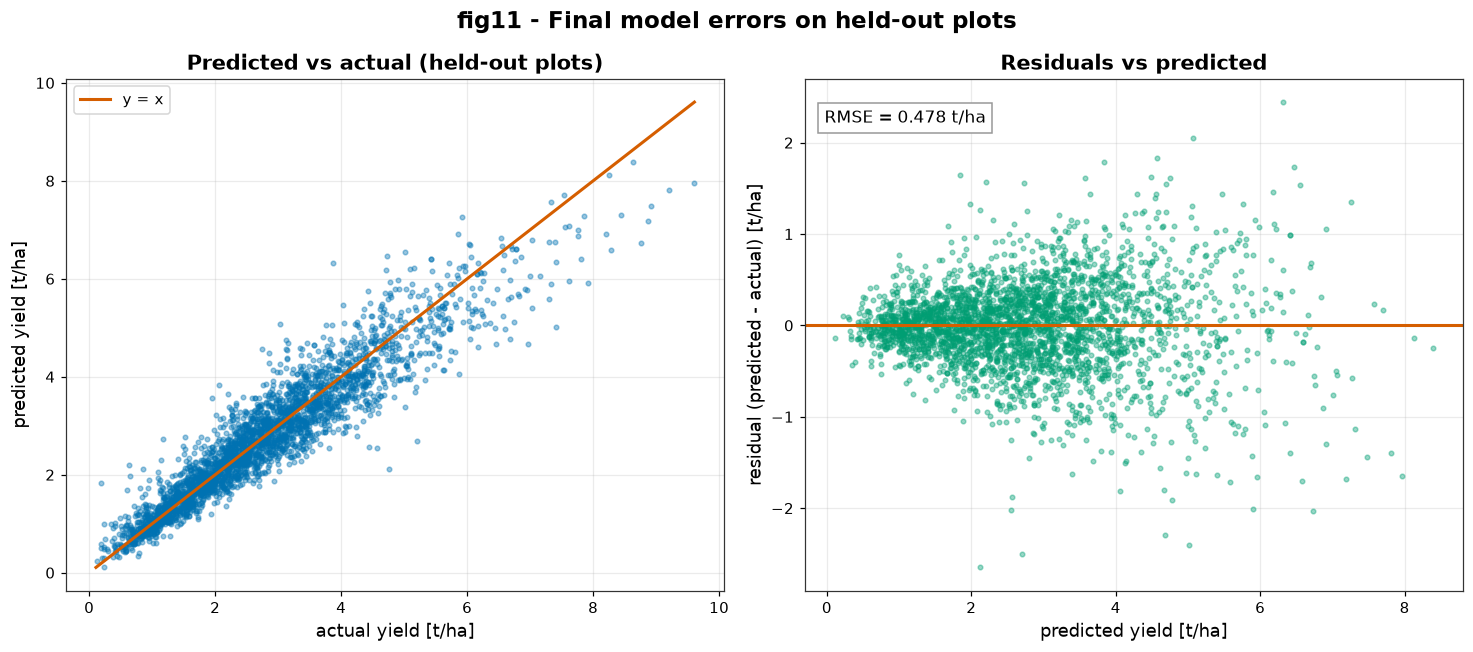

saved figures\fig11_predicted_vs_actual_residuals.png (338 KB)


In [13]:
hold = arts["holdout"]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6))
lo = min(hold.actual_yield_tons_per_ha.min(), hold.predicted_yield_tons_per_ha.min())
hi = max(hold.actual_yield_tons_per_ha.max(), hold.predicted_yield_tons_per_ha.max())
axes[0].scatter(hold.actual_yield_tons_per_ha, hold.predicted_yield_tons_per_ha,
                s=9, alpha=0.4, color="#0072B2")
axes[0].plot([lo, hi], [lo, hi], color="#D55E00", lw=2, label="y = x")
axes[0].set_xlabel("actual yield [t/ha]")
axes[0].set_ylabel("predicted yield [t/ha]")
axes[0].set_title("Predicted vs actual (held-out plots)")
axes[0].legend()

axes[1].scatter(hold.predicted_yield_tons_per_ha, hold.residual, s=9, alpha=0.4,
                color="#009E73")
axes[1].axhline(0, color="#D55E00", lw=2)
axes[1].set_xlabel("predicted yield [t/ha]")
axes[1].set_ylabel("residual (predicted - actual) [t/ha]")
axes[1].set_title("Residuals vs predicted")
rmse = float(np.sqrt((hold.residual ** 2).mean()))
axes[1].text(0.03, 0.94, f"RMSE = {rmse:.3f} t/ha", transform=axes[1].transAxes,
             va="top", fontsize=11, bbox=dict(fc="white", ec="#999999"))
fig.suptitle("fig11 - Final model errors on held-out plots", fontsize=15, fontweight="bold")
fig.tight_layout()
save(fig, "fig11_predicted_vs_actual_residuals.png")

captions["fig11_predicted_vs_actual_residuals.png"] = (
    f"Left: predictions against actual yield for the 3,018 held-out plots with the y = x line. "
    f"Right: residuals against predictions, centered near zero (RMSE {rmse:.3f} t/ha). Errors grow "
    f"at high yields - the model under-predicts the best plots "
    f"({100 * (hold.residual[hold.actual_yield_tons_per_ha > 6] < 0).mean():.0f}% of plots above "
    f"6 t/ha are under-predicted) - which is the bias we look at in D7.")

## fig12 - Permutation importance of the top features (weather-derived highlighted)

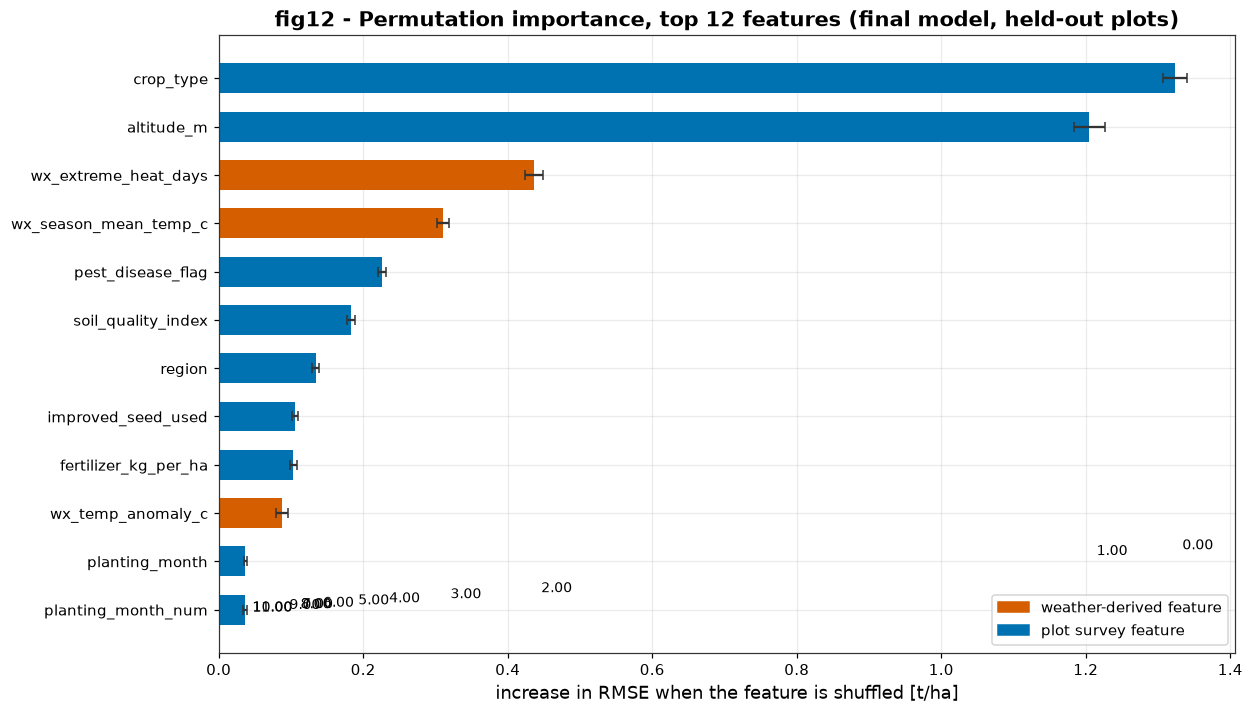

saved figures\fig12_feature_importance.png (91 KB)


In [14]:
perm = arts["perm"].sort_values("importance_mean", ascending=False).head(12).iloc[::-1]
colors = ["#D55E00" if w else "#0072B2" for w in perm.is_weather_derived]
fig, ax = plt.subplots(figsize=(11.5, 6.6))
ax.barh(perm.feature, perm.importance_mean, xerr=perm.importance_std,
        color=colors, height=0.62, error_kw=dict(ecolor="#333333", capsize=3))
ax.set_xlabel("increase in RMSE when the feature is shuffled [t/ha]")
ax.set_title("fig12 - Permutation importance, top 12 features (final model, held-out plots)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#D55E00", label="weather-derived feature"),
                   Patch(color="#0072B2", label="plot survey feature")], loc="lower right")
for x, v in zip(perm.importance_mean, perm.index):
    ax.text(x + 0.01, x, f"{v:.2f}", va="center", fontsize=9)
fig.tight_layout()
save(fig, "fig12_feature_importance.png")

n_wx = int(perm.is_weather_derived.sum())
top_wx = perm[perm.is_weather_derived].feature.tolist()
captions["fig12_feature_importance.png"] = (
    f"Permutation importance of the top 12 features; shuffling the best feature "
    f"{perm.feature.iloc[-1]} raises RMSE by {perm.importance_mean.max():.2f} t/ha. "
    f"{n_wx} of the top 12 are weather-derived ({', '.join(top_wx)}), so the weather join earns its "
    f"place: without it the ablation in D5 loses "
    f"{100 * (arts['ablation'].loc[0, 'rmse'] - arts['ablation'].loc[1, 'rmse']) / arts['ablation'].loc[1, 'rmse']:.1f}% "
    f"of accuracy. crop_type and altitude dominate because yield potential is set first by the crop "
    f"and then by elevation.")

## Write `figures/figure_captions.md`

In [15]:
expected = ["fig01_missingness.png", "fig02_before_after_cleaning.png",
            "fig03_yield_distribution.png", "fig04_region_crop_heatmap.png",
            "fig05_correlation_heatmap.png", "fig06_climate_by_region.png",
            "fig07_yield_vs_season_temp.png", "fig08_price_trends.png",
            "fig09_revenue_by_crop_region.png", "fig10_model_comparison.png",
            "fig11_predicted_vs_actual_residuals.png", "fig12_feature_importance.png"]
missing = [f for f in expected if f not in captions]
files_missing = [f for f in expected if not (Path("figures") / f).exists()]
assert not missing, "captions missing for: " + str(missing)
assert not files_missing, "figure files missing: " + str(files_missing)

lines = ["# Figure captions (Deliverable C)",
         "",
         "One caption per figure: what it shows, and the takeaway. Every figure is generated by "
         "`notebooks/03_visualizations.ipynb` at 150 dpi.",
         ""]
for name in expected:
    lines += ["## " + name, "", captions[name], ""]
out = Path("figures/figure_captions.md")
out.write_text(NL.join(lines), encoding="utf-8")
print("wrote", out, "with", len(expected), "captions (", out.stat().st_size, "bytes )")
print("figure files present:", len(list(Path('figures').glob('fig*.png'))))

wrote figures\figure_captions.md with 12 captions ( 4526 bytes )
figure files present: 12
